In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.model_selection import train_test_split, TimeSeriesSplit
import pandas as pd

In [11]:
ticker_symbol = "MSFT" 
ticker = yf.Ticker(ticker_symbol)
df = ticker.history(start='2020-01-01')
df.head()
df.dropna()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,1653.0,3.229042e+02,1.002832e+02,1.298654e+02,2.381887e+02,3.137938e+02,4.091438e+02,5.508301e+02
High,1653.0,3.260637e+02,1.007209e+02,1.332398e+02,2.414074e+02,3.159769e+02,4.116331e+02,5.510484e+02
Low,1653.0,3.195970e+02,9.962094e+01,1.256096e+02,2.366138e+02,3.096431e+02,4.046675e+02,5.373668e+02
Close,1653.0,3.229519e+02,1.001801e+02,1.283583e+02,2.392843e+02,3.136568e+02,4.084447e+02,5.386586e+02
Volume,1653.0,2.846496e+07,1.341572e+07,5.855900e+06,2.007530e+07,2.526260e+07,3.293560e+07,1.862016e+08
Dividends,1653.0,1.090139e-02,8.773225e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.100000e-01
Stock Splits,1653.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [12]:
target = "Open"
X = df.drop(columns=target)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X.shape, y.shape

((1653, 6), (1653,))

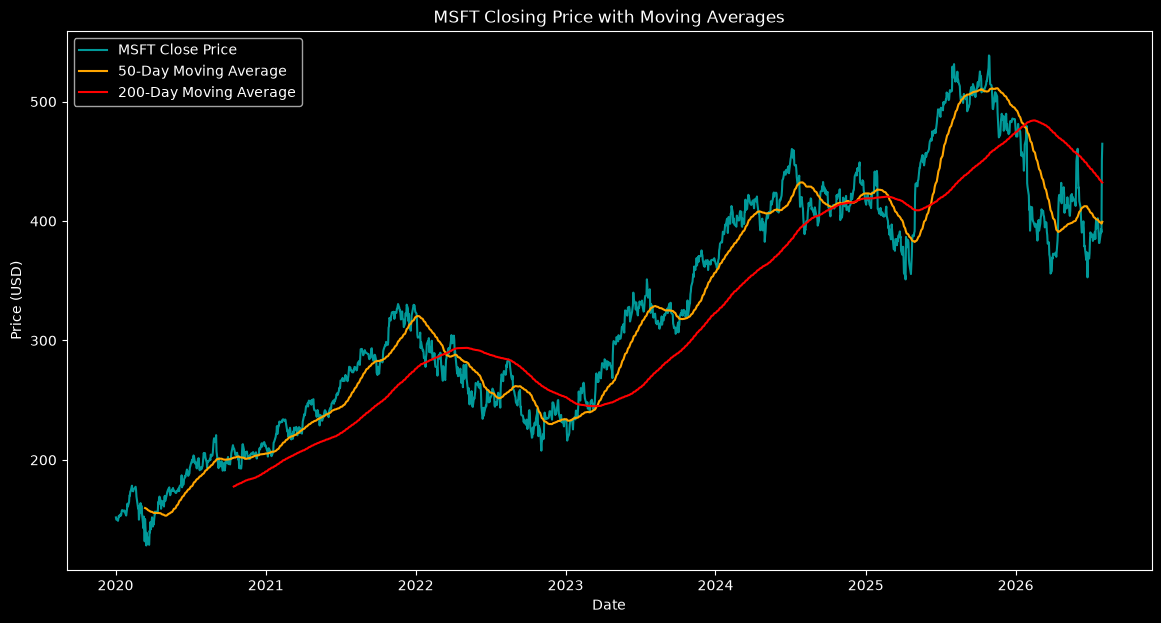

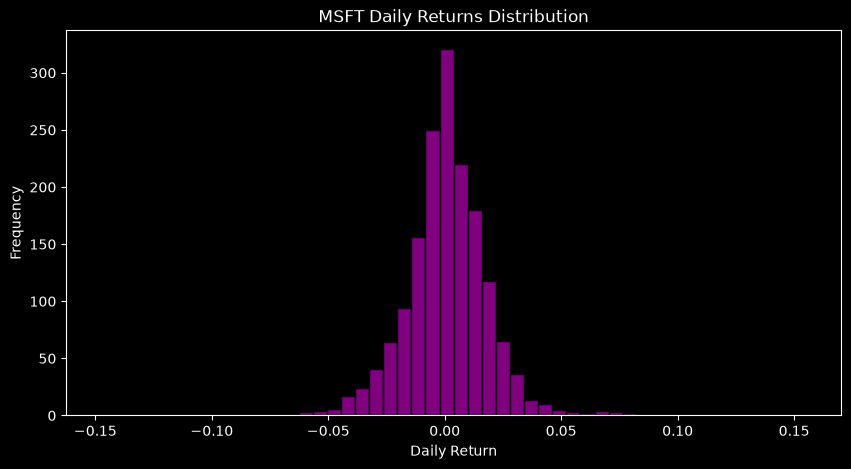

In [13]:
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

# 4. Visualize Closing Price and Moving Averages
plt.style.use('dark_background')
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label=f'{ticker_symbol} Close Price', color='cyan', alpha=0.6)
plt.plot(df.index, df['MA_50'], label='50-Day Moving Average', color='orange')
plt.plot(df.index, df['MA_200'], label='200-Day Moving Average', color='red')
plt.title(f'{ticker_symbol} Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# 5. Analyze Daily Returns
df['Daily_Return'] = df['Close'].pct_change()
plt.figure(figsize=(10, 5))
plt.hist(df['Daily_Return'].dropna(), bins=50, color='purple', edgecolor='black')
plt.title(f'{ticker_symbol} Daily Returns Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

In [15]:
# CREATE CLASSIFICATION TARGET: Predict if next day's Open is higher than today's Open
df['Target_Direction'] = (df['Open'].shift(-1) > df['Open']).astype(int)
df = df.dropna()

# Define numerical features for correlation and modeling
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_50', 'MA_200', 'Daily_Return']
X = df[features]
y = df['Target_Direction']

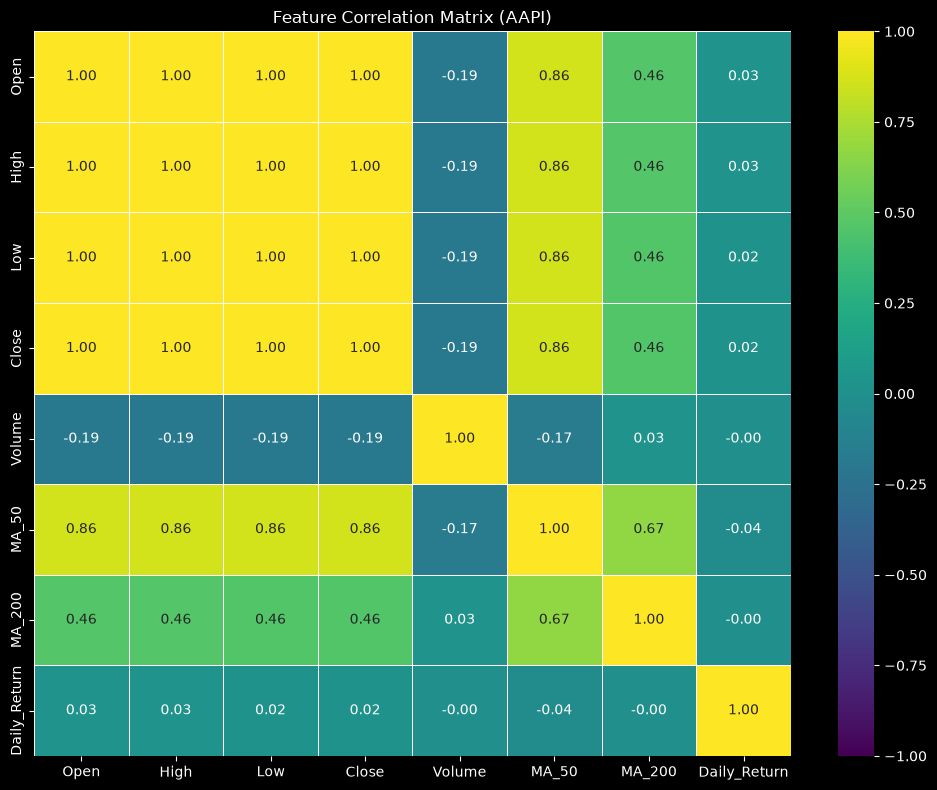

In [21]:
import seaborn as sns

plt.figure(figsize=(10, 8))
correlation_matrix = X.corr()

# Generate heatmap using Seaborn
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='viridis', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)
plt.title(f'Feature Correlation Matrix ({ticker_symbol})')
plt.tight_layout()
plt.show()